In [1]:
import sys
sys.path.insert(0, "../src")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from features import (SR, FRAME, HOP, FREQS, SCALAR_FEATURES, split_into_frames, magnitude_spectrum,
                      energy_db, zero_crossing_rate, extract_features)
from dataset import load_wav, list_clips, speech_labels, mix, build_frame_table

results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)

Notebook 01'den farkı: pandas (tablo) ve feature fonksiyonları geliyor; tabloların kaydedileceği results klasörü oluşturuluyor.

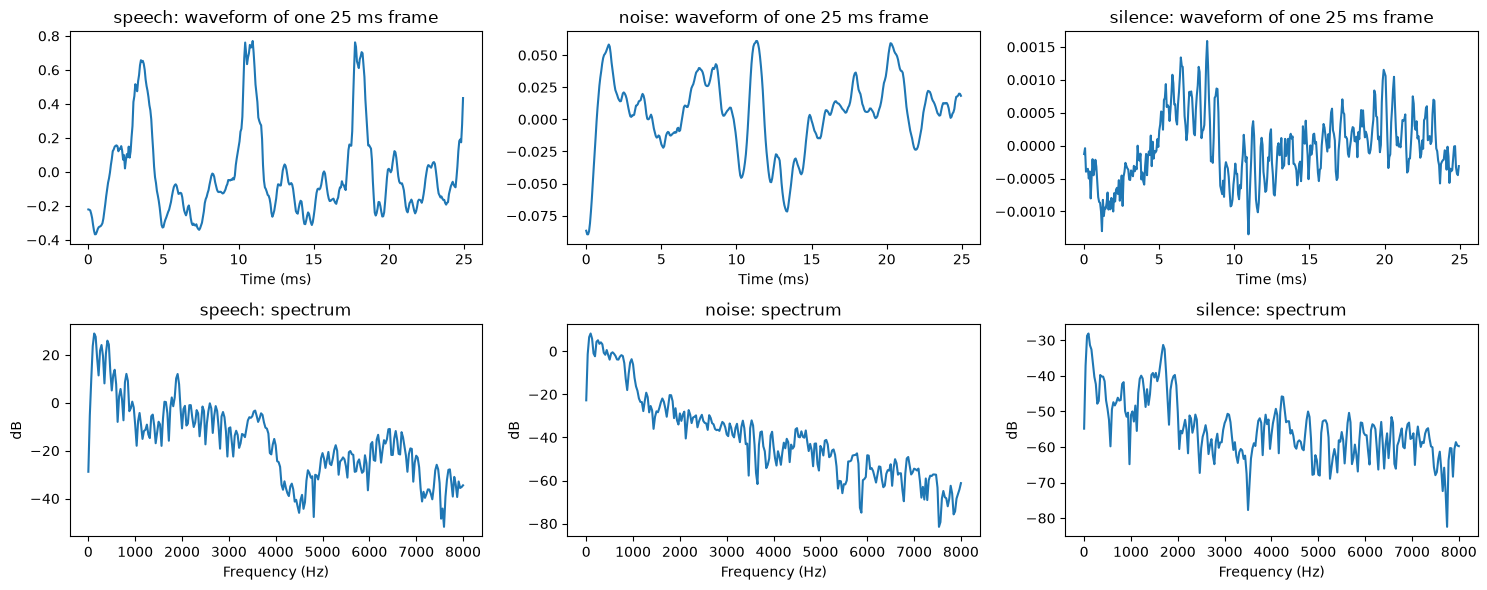

In [2]:
clean = load_wav(list_clips("train", "clean_speech")[0])
noise = load_wav(list_clips("train", "noise_only")[0])

clean_frames = split_into_frames(clean)
noise_frames = split_into_frames(noise)
clean_db = energy_db(clean_frames)
is_speech = speech_labels(clean)

speech_index = np.argmax(clean_db)                            # loudest frame: almost always a vowel
noise_index = len(noise_frames) // 2                          # a frame from the middle of the noise clip
real_pauses = np.where(~is_speech & (clean_db > -90))[0]      # pauses, without the digital zeros
silence_index = real_pauses[len(real_pauses) // 2]

examples = {
    "speech": clean_frames[speech_index],
    "noise": noise_frames[noise_index],
    "silence": clean_frames[silence_index],
}

fig, axes = plt.subplots(2, 3, figsize=(15, 6))
for column, (name, frame) in enumerate(examples.items()):
    axes[0, column].plot(np.arange(FRAME) / SR * 1000, frame)
    axes[0, column].set_title(f"{name}: waveform of one 25 ms frame"); axes[0, column].set_xlabel("Time (ms)")
    spectrum = magnitude_spectrum(frame[None, :])[0]
    axes[1, column].plot(FREQS, 20 * np.log10(spectrum + 1e-10))
    axes[1, column].set_title(f"{name}: spectrum"); axes[1, column].set_xlabel("Frequency (Hz)"); axes[1, column].set_ylabel("dB")
plt.tight_layout(); plt.show()

Üst sıra: sesin kendisi

Bu grafikler sesin 25 ms’lik (saniyenin kırkta biri) küçük bir parçasını gösteriyor. Çizgi yukarı aşağı gidiyor, çünkü ses bir titreşim.

Sol üst — konuşma:

Üç tane sivri tepe var.
Tepeler eşit aralıklı.
Yani dalga aynı şekli tekrar ediyor.
Neden: ses telleri düzenli titreşiyor.

Orta üst — gürültü:

İniş çıkışlar var ama düzensiz.
Hiçbir şekil tekrar etmiyor.
Neden: uğultunun düzenli bir kaynağı yok.

Sağ üst — sessizlik:

Rastgele küçük titreşimler.
Soldaki sayılara bak: 0,001 civarı. Konuşmada 0,8'di.
Yani çok, çok kısık.

Üst sıradan çıkan iki sonuç:

Konuşma kendini tekrar eder, gürültü etmez.
Sessizlik diğerlerinden çok daha kısıktır.
Alt sıra: sesin içindeki frekanslar

Bu grafikler aynı parçanın içinde hangi frekanstan ne kadar olduğunu gösteriyor. Sol taraf kalın sesler, sağ taraf ince sesler. Çizgi ne kadar yukarıdaysa o frekanstan o kadar çok var.

Sol alt — konuşma:

Çizgi tırtıklı, bir sürü tepe var.
2000 civarında bir tümsek daha var.
Yani konuşmanın belirli frekansları güçlü.

Orta alt — gürültü:

Çizgi soldan sağa düzgünce iniyor.
Belirgin tepe yok.
Yani gürültü kalın seslerden oluşuyor, belirli bir yapısı yok.

Sağ alt — sessizlik:

Gürültüye benziyor.
Ama soldaki sayılar çok daha düşük (−30 ile −80 arası).

Alt sıradan çıkan sonuç:
Konuşmanın spektrumu tepeli, gürültününki düz.

Bunun feature’larla ilgisi

Her feature bu farklardan birini sayıya çeviriyor:

Gördüğün fark	Bunu ölçen feature
Ses ne kadar yüksek	energy_db
Dalga kendini tekrar ediyor mu	harmonicity
Spektrum tepeli mi düz mü	flatness

In [3]:
frame = examples["speech"]

# Energy: mean of the squared samples, then decibels
energy_by_hand = 10 * np.log10(np.mean(frame ** 2))

# Zero-crossing rate: count the places where the sign changes, divide by the number of sample pairs
sign_changes = np.sum((frame[1:] < 0) != (frame[:-1] < 0))
zcr_by_hand = sign_changes / (len(frame) - 1)

print("energy_db   by hand:", round(energy_by_hand, 2), "| function:", round(energy_db(frame[None, :])[0], 2))
print("zcr         by hand:", round(zcr_by_hand, 4), "| function:", round(zero_crossing_rate(frame[None, :])[0], 4))
print("sign changes in 25 ms:", sign_changes)

energy_db   by hand: -11.36 | function: -11.36
zcr         by hand: 0.0426 | function: 0.0426
sign changes in 25 ms: 17


“Feature fonksiyonlarının ne yaptığını görmek için tek bir konuşma parçasında iki feature’ı elle hesapladım ve fonksiyonun sonucuyla karşılaştırdım. İkisi de aynı çıktı.

Enerji için 400 sayının karesini alıp ortalamasını hesapladım ve dB’ye çevirdim: −11,36 dB.

ZCR için dalganın sıfır çizgisini kaç kez geçtiğini saydım: 25 ms’de 17 kez. Bunu 399 komşu çifte bölünce 0,0426 çıktı.”
−11,36 dB: Yüksek sesli bir parça. Notebook 01'deki enerji grafiğinde konuşma −10 ile −20 dB arasındaydı, duraklamalar −60 dB civarındaydı. Bu parça konuşma tarafında.
0,0426: Komşu sayı çiftlerinin yaklaşık %4'ünde işaret değişmiş. Dalga yavaş salınıyor.

ZCR of the vowel frame we looked at: 0.043
Lowest ZCR among speech frames     : 0.01
Typical (median) ZCR of speech     : 0.043
Highest ZCR among speech frames    : 0.802


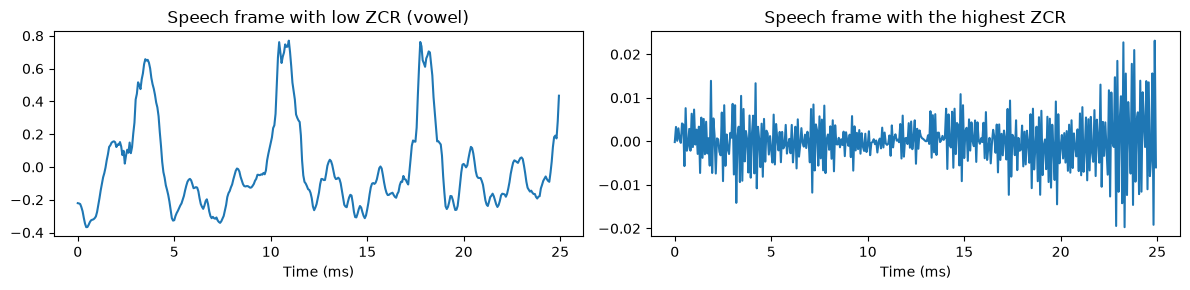

In [4]:
zcr_all = zero_crossing_rate(clean_frames)                 # ZCR of every frame of the clean clip
speech_zcr = zcr_all[is_speech]                            # only the frames labelled speech

print("ZCR of the vowel frame we looked at:", round(zcr_all[speech_index], 3))
print("Lowest ZCR among speech frames     :", round(speech_zcr.min(), 3))
print("Typical (median) ZCR of speech     :", round(np.median(speech_zcr), 3))
print("Highest ZCR among speech frames    :", round(speech_zcr.max(), 3))

# Draw the speech frame with the highest ZCR next to the vowel frame
hissy_index = np.where(is_speech)[0][np.argmax(speech_zcr)]
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(np.arange(FRAME) / SR * 1000, clean_frames[speech_index]); axes[0].set_title("Speech frame with low ZCR (vowel)")
axes[1].plot(np.arange(FRAME) / SR * 1000, clean_frames[hissy_index]); axes[1].set_title("Speech frame with the highest ZCR")
for ax in axes:
    ax.set_xlabel("Time (ms)")
plt.tight_layout(); plt.show()

zcr_all: Temiz kaydın bütün parçalarının ZCR’ı.
speech_zcr: Bunların içinden yalnızca “konuşma” etiketli olanlar.
Dört print: Baktığımız parçanın ZCR’ı, konuşma parçaları içindeki en düşük, tipik ve en yüksek ZCR.
hissy_index: ZCR’ı en yüksek olan konuşma parçasının sırası.
Grafik: Solda az önceki parça, sağda ZCR’ı en yüksek parça.
	ZCR
En düşük konuşma parçası	0,01
Tipik konuşma parçası	0,043
En yüksek konuşma parçası	0,802
Aynı kaydın içinde, hepsi “konuşma” etiketli parçalarda ZCR 0,01 ile 0,80 arasında değişiyor. En yüksek, en düşüğün 80 katı.
Tipik değer 0,043. Hücre 3'te baktığımız parça da tam bu değerdeydi, yani sıradan bir konuşma parçasıymış.
Grafik
Sol: Yavaş, düzenli salınım. 25 ms’de 17 kez sıfırı geçiyor.
Sağ: Çok hızlı, düzensiz titreşim. Neredeyse her iki sayıdan birinde işaret değişiyor.
Dikey eksenlere bak: Soldaki 0,8'e çıkıyor, sağdaki 0,02'ye. Yani ZCR’ı en yüksek parça aynı zamanda çok kısık.

In [5]:
three_frames = pd.DataFrame({
    "speech": extract_features(clean).iloc[speech_index],
    "noise": extract_features(noise).iloc[noise_index],
    "silence": extract_features(clean).iloc[silence_index],
}).loc[SCALAR_FEATURES]
display(three_frames.round(3))

,speech,noise,silence
energy_db,-11.362,-30.585,-65.785
zcr,0.043,0.028,0.155
centroid,869.686,581.183,2166.906
flatness,0.002,0.001,0.088
flux,0.075,0.090,0.084
band_ratio,0.331,0.384,0.457
harmonicity,0.649,0.123,0.172


In [6]:
test = build_frame_table("test")
print("Frames:", len(test))
display(test.groupby(["condition", "klass"]).size().unstack(fill_value=0))

Frames: 199800


klass,noise,silence,speech
condition,,,
clean speech,0,6427,33533
noise only,39960,0,0
speech + noise 0 dB,6427,0,33533
speech + noise 10 dB,6427,0,33533
speech + noise 20 dB,6427,0,33533


Toplam 199 800 parça. 20 konuşma kaydı dört koşulda (temiz, 20, 10, 0 dB) ve 20 gürültü kaydı; her kayıt 20 saniye, yaklaşık 2000 parça.
Temiz konuşmada parçaların %84'ü konuşma (33 533), %16'sı sessizlik (6 427). Notebook 01'deki üç kayıtla aynı oran; veri tutarlı.
Gürültü eklenince 6 427 sessizlik parçası noise sütununa geçiyor. Notebook 01'de gördüğün şeyin aynısı, bu kez 20 kayıtla
Sınıf başına toplam
Sınıf	Parça sayısı
speech	134 132
noise	59 241
silence	6 427

Sessizlik en küçük sınıf: konuşmanın yirmide biri. Bunu aklında tut; notebook 03'te düz accuracy yerine balanced accuracy kullanmamızın nedeni bu.

In [7]:
groups = {
    "silence": test["klass"] == "silence",
    "noise": test["klass"] == "noise",
    "speech (clean)": (test["klass"] == "speech") & (test["condition"] == "clean speech"),
    "speech (10 dB noise)": (test["klass"] == "speech") & (test["condition"] == "speech + noise 10 dB"),
}
table1 = pd.DataFrame({name: test.loc[mask, SCALAR_FEATURES].median() for name, mask in groups.items()})
display(table1.round(3))
table1.round(4).to_csv(results_dir / "table1_feature_values.csv")

,silence,noise,speech (clean),speech (10 dB noise)
energy_db,-51.910,-32.978,-22.464,-21.806
zcr,0.115,0.043,0.060,0.068
centroid,1966.695,790.850,1097.034,1090.256
flatness,0.048,0.001,0.004,0.005
flux,0.073,0.097,0.063,0.070
band_ratio,0.194,0.305,0.382,0.414
harmonicity,0.237,0.230,0.512,0.419


Soru 1: Sessizliği diğerlerinden ne ayırıyor?

Sessizlik sütununu diğer üçüyle karşılaştır.

energy_db: −52'ye karşı −33 ve −22. En az 19 dB fark.
zcr: 0,115'e karşı 0,04–0,07. Yaklaşık iki katı.
centroid: 1967 Hz’e karşı 800–1100 Hz. Yaklaşık iki katı.
flatness: 0,048'e karşı 0,001–0,005. On kattan fazla.

Dört feature sessizlikte belirgin biçimde farklı. Üç parçada gördüğümüz örüntü bütün veride de tutuyor.

Soru 2: Konuşmayı gürültüden ne ayırıyor?

Gürültü sütununu konuşma sütunlarıyla karşılaştır.

harmonicity: 0,23'e karşı 0,51. İki katından fazla; en net fark bu.
energy_db: −33'e karşı −22. Yaklaşık 10 dB fark var.
band_ratio: 0,31'e karşı 0,38. Küçük bir fark.
centroid: 791'e karşı 1097. Orta düzeyde bir fark.
zcr, flatness, flux: Birbirine yakın.
Soru 3: Gürültü eklenince hangi feature bozuluyor?

Son iki sütunu karşılaştır (temiz konuşma ile 10 dB gürültülü konuşma).

harmonicity: 0,51'den 0,42'ye düşüyor. Gürültünün değerine (0,23) doğru kayıyor. Konuşmayı en iyi ayıran feature, gürültüden de en çok etkilenen.
Diğerleri: Neredeyse aynı kalıyor.
Dikkat çeken iki şey

Sessizlik ile gürültünün harmonicity’si aynı (0,237 ve 0,230). Yani harmonicity “ses var mı” sorusunda işe yaramaz; yalnızca “konuşma mı” sorusunda yarar.

Flux hiçbir şeyi ayırmıyor. Dört sütunda da 0,06–0,10 arası.

Özet
Soru	Tipik değerlere göre işe yarar görünen
Ses var mı	energy, flatness, zcr, centroid
Konuşma var mı	harmonicity, sonra energy
Bu tablonun söyleyemediği

Ortanca tek bir sayı; yayılımı göstermez. Az önce gördün: konuşmanın tipik ZCR’ı 0,043'tü ama 0,80'e kadar çıkan parçalar vardı. İki sınıfın ortancası farklı olsa bile değerleri büyük ölçüde üst üste biniyor olabilir. O durumda feature ikisini yine ayıramaz.

Örneğin enerji: gürültü −33, konuşma −22. Fark var gibi. Ama bazı gürültü kayıtları yüksek sesli, bazı konuşma parçaları kısıksa bu fark pratikte işe yaramayabilir. Bunu ortancadan göremeyiz.

Bu yüzden sıradaki hücre histogramları çiziyor: her sınıfın değerlerinin tamamını.

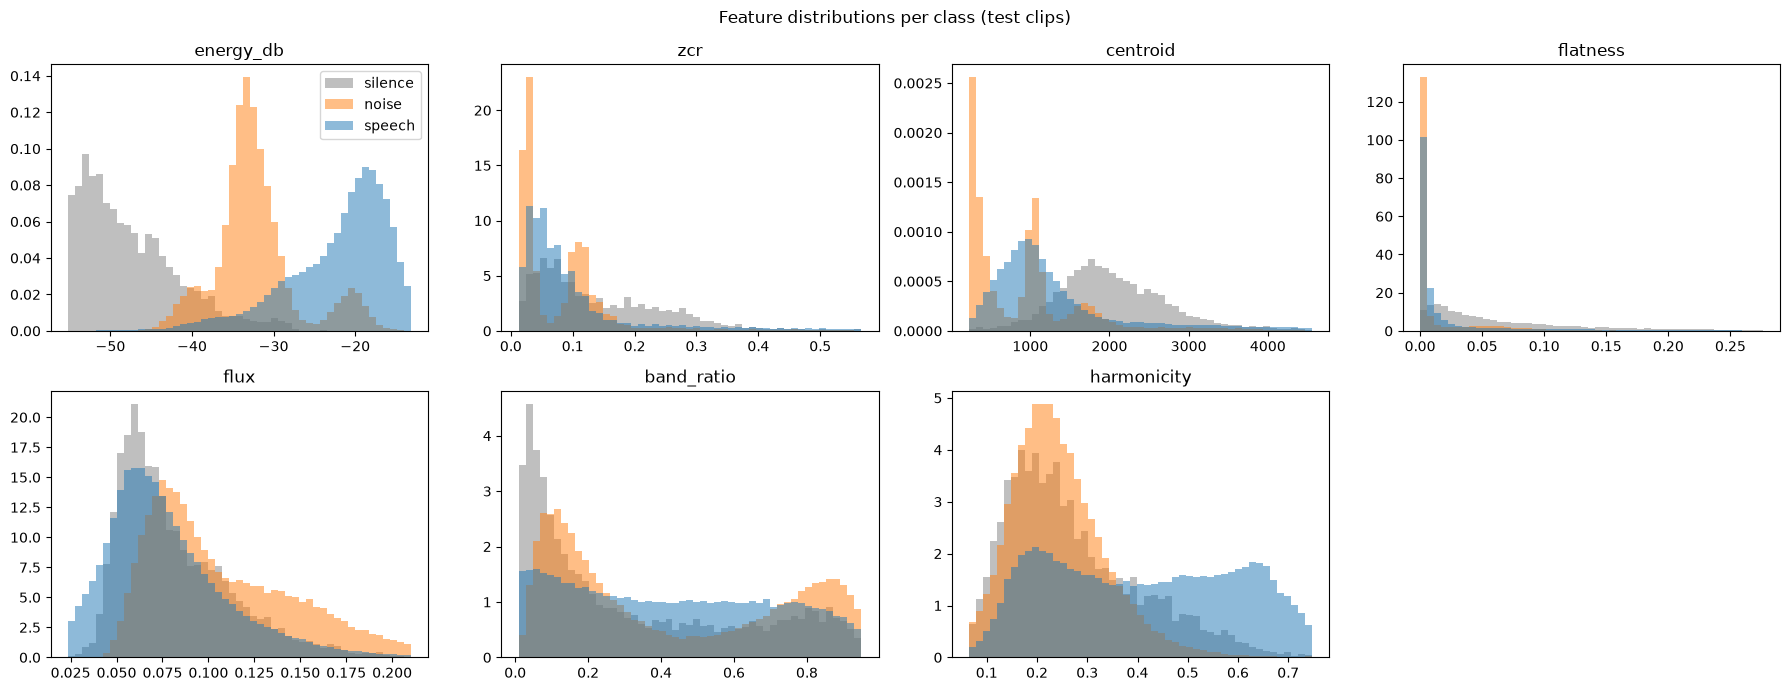

In [8]:
colours = {"silence": "grey", "noise": "tab:orange", "speech": "tab:blue"}

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.ravel()
for ax, feature in zip(axes, SCALAR_FEATURES):
    low, high = np.percentile(test[feature], [1, 99])
    bins = np.linspace(low, high, 50)
    for klass, colour in colours.items():
        ax.hist(test.loc[test["klass"] == klass, feature], bins=bins, density=True, alpha=0.5, color=colour, label=klass)
    ax.set_title(feature)
axes[0].legend()
axes[-1].axis("off")
plt.suptitle("Feature distributions per class (test clips)"); plt.tight_layout(); plt.show()

Yedi küçük grafik çizer, her feature için bir tane. Gri sessizlik, turuncu gürültü, mavi konuşma. Grafiği gönder; nasıl okunacağını onun üzerinden anlatacağım.

Her küçük grafik bir feature.
Yatay eksen feature’ın değeri, dikey eksen o değerin ne kadar sık görüldüğü.
Gri sessizlik, turuncu gürültü, mavi konuşma.
İki renk ayrı tepeler yapıyorsa o feature o iki sınıfı ayırır.
İki renk üst üste biniyorsa ayıramaz. Üst üste binen yerler koyu, kahverengimsi görünür; o renk ayrı bir sınıf değil, iki rengin karışımı.
Tek tek

energy_db — üç ayrı tepe.
Sessizlik solda (−55 ile −40), gürültü ortada (−33 civarı), konuşma sağda (−18 civarı). En temiz ayrım bu grafikte. Ama dikkat: mavinin sola doğru uzun bir kuyruğu var, −40'a kadar iniyor ve turuncunun altından geçiyor. Yani kısık konuşma parçaları gürültüyle aynı seviyede.

harmonicity — konuşmanın yarısını ayırıyor.
Sessizlik ve gürültü tamamen üst üste, 0,2 civarında tepe yapıyor. Konuşma ise 0,15'ten 0,7'ye kadar yayılmış. 0,45'in sağında neredeyse yalnızca mavi var. Yani:

Harmonicity yüksekse → konuşma.
Harmonicity düşükse → bilemeyiz; gürültü de olabilir, konuşmanın perdesiz bir parçası da.

centroid — sessizliği kısmen ayırıyor.
Gri sağda geniş bir tepe (1500–3000 Hz). Turuncu ve mavi solda, 1000 Hz civarında üst üste.

zcr — çoğu üst üste.
Üç renk de 0–0,15 arasında yığılmış. Grinin sağa doğru bir kuyruğu var, o kadar.

flux — tamamen üst üste.
Üç renk aynı yerde. Turuncunun sağ kuyruğu biraz daha uzun.

band_ratio — tamamen üst üste.
Her renk 0'dan 1'e kadar yayılmış.

flatness — okunamıyor.
Bütün değerler 0'a yığılmış, tek bir çubuk görünüyor. Grafik bu haliyle bir şey söylemiyor; Tablo 1'deki sayılara (sessizlik 0,048, diğerleri 0,001–0,005) güvenmek gerekiyor.

Tablo 1 ile karşılaştır
Feature	Tablo 1 ne dedi	Grafik ne ekledi
energy	Üç sınıf farklı seviyede	Doğru, ama kısık konuşma gürültüyle karışıyor
harmonicity	Konuşma 0,51, gürültü 0,23	Konuşmanın yarısı gürültüyle aynı bölgede
centroid	Sessizlik iki kat yüksek	Doğru; konuşma ile gürültü ayrılmıyor
zcr	Sessizlik iki kat yüksek	Fark var ama büyük bölümü üst üste
flux	Fark yok	Doğrulandı
Buradan çıkan asıl sonuç

Konuşmayı gürültüden tek başına temiz ayıran bir feature yok. Enerji en iyisi, ama kuyruklar karışıyor. Harmonicity yalnızca perdeli sesleri yakalıyor.

Bu iki feature farklı şeyleri yakaladığı için birlikte kullanılınca daha iyi sonuç vermeleri beklenir: kısık ama perdeli bir parçayı harmonicity kurtarır, perdesiz ama yüksek sesli bir parçayı enerji. Bu şimdilik bir beklenti; notebook 03'te feature’ları birleştirip ölçeceğiz.
Enerji grafiğinde notebook 01'de gördüğün −100 dB’lik dijital sıfırlar görünmüyor. Silinmediler; grafik en uçtaki %1'lik değerleri çizmiyor ki geri kalanı okunabilsin.

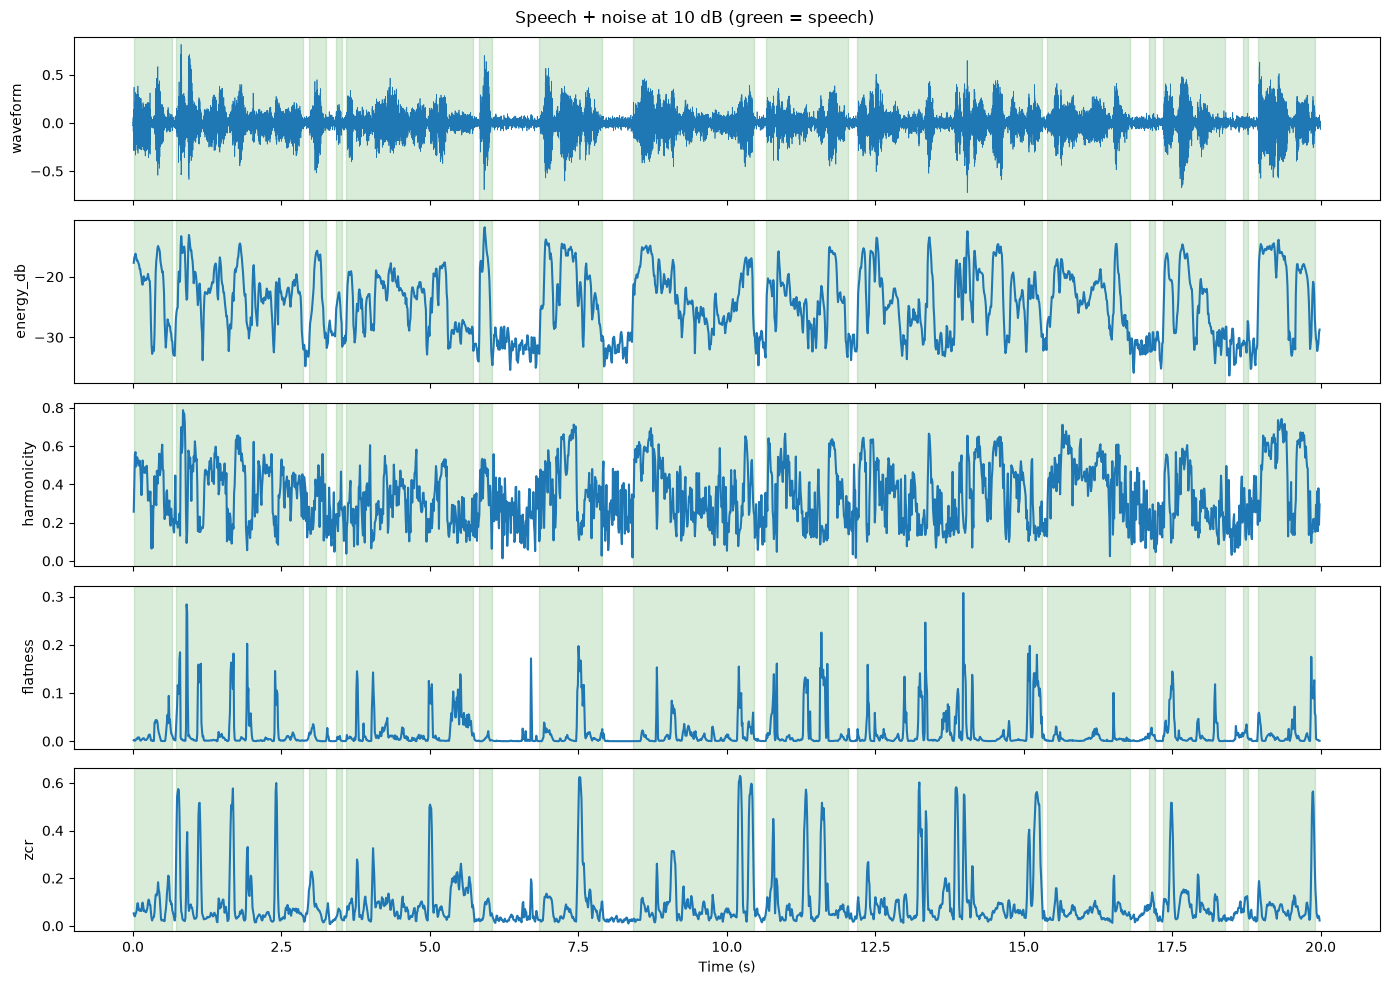

In [9]:
clean = load_wav(list_clips("test", "clean_speech")[0])
noise = load_wav(list_clips("test", "noise_only")[0])
noisy = mix(clean, noise, 10)
is_speech = speech_labels(clean)
feats = extract_features(noisy)
frame_time = (np.arange(len(feats)) * HOP + FRAME / 2) / SR

shown = ["energy_db", "harmonicity", "flatness", "zcr"]
fig, axes = plt.subplots(len(shown) + 1, 1, figsize=(14, 10), sharex=True)
axes[0].plot(np.arange(len(noisy)) / SR, noisy, linewidth=0.5); axes[0].set_ylabel("waveform")
for ax, feature in zip(axes[1:], shown):
    ax.plot(frame_time, feats[feature]); ax.set_ylabel(feature)
for ax in axes:
    low, high = ax.get_ylim()
    ax.fill_between(frame_time, low, high, where=is_speech, color="green", alpha=0.15)
    ax.set_ylim(low, high)
axes[-1].set_xlabel("Time (s)")
plt.suptitle("Speech + noise at 10 dB (green = speech)"); plt.tight_layout(); plt.show()

Amaç: Şimdiye kadar parçalara tek tek ya da toplu sayılar olarak baktık. Bu hücre tek bir kaydı baştan sona izliyor: konuşma başlayıp bittikçe feature’lar nasıl hareket ediyor?

Kısa kısa:

İlk iki satır: Test klasöründen bir temiz konuşma ve bir gürültü kaydı yükler.
mix(clean, noise, 10): İkisini 10 dB SNR’da karıştırır. Artık gürültülü bir kaydımız var.
speech_labels(clean): Etiketleri temiz kayıttan alır. Gürültülü kayıtta konuşmanın nerede olduğunu bu sayede kesin biliyoruz.
extract_features(noisy): Feature’ları gürültülü kayıttan hesaplar. Gerçek bir dedektörün göreceği şey bu.
shown: Çizilecek dört feature.
İlk for: Her feature’ı zaman içinde çizer.
İkinci for: Konuşmanın olduğu yerleri bütün grafiklerde yeşile boyar.

Beklenen: Alt alta beş grafik. En üstte dalga şekli, altında enerji, harmonicity, flatness ve ZCR. Hepsinde aynı yeşil bölgeler.
Bu grafik, konuşmanın zaman içinde nasıl göründüğünü çok iyi gösteriyor. Yeşil konuşma, beyaz duraklama (gürültülü kayıtta duraklamada yalnızca gürültü var).

Tek tek

Dalga şekli (en üst):
Yeşil bölgelerde dalga büyük, beyaz bölgelerde ince bir şerit. O ince şerit eklediğimiz gürültü; hiçbir yerde sıfıra inmiyor.

energy_db:

Beyaz bölgelerde (örneğin 6–6,8 saniye ve 16,8–17,2 saniye) eğri −30 ile −33 arasında, düz. Bu gürültünün seviyesi.
Yeşil bölgelerde −15 ile −25 arasına çıkıyor.
Ama yeşilin içinde de sık sık −30'a kadar iniyor. Kelimelerin arasındaki ve içindeki kısık anlar bunlar.

harmonicity:

Çok oynak; parçadan parçaya 0,1 ile 0,7 arasında zıplıyor.
0,6'nın üstündeki tepeler yalnızca yeşil bölgelerde.
Ama yeşilin içinde de sık sık 0,2'ye düşüyor; beyaz bölgelerde de 0,2–0,4 arasında.
Yani yüksek tepeler konuşmayı gösteriyor, düşük değerler bir şey söylemiyor. Histogramda gördüğün şeyin aynısı.

flatness ve zcr:

İkisi birlikte hareket ediyor: aynı anlarda sivri tepeler yapıyorlar.
Tepelerin hepsi yeşil bölgelerin içinde.
Tepelerin dışında, yeşil olsun beyaz olsun, ikisi de sıfıra yakın.
Yani bu iki feature konuşmanın yalnızca belirli anlarını işaretliyor, tamamını değil.
Bu grafikten çıkan iki sonuç

1. Hiçbir eğri yeşil bölgeleri tam olarak takip etmiyor.
Enerji en yakını, ama konuşmanın içinde gürültü seviyesine inen çukurları var. Tek bir parçaya bakıp karar verirsek o çukurlarda “konuşma yok” deriz.

2. Konuşma oynak, duraklama düz.
Beyaz bölgelerde enerji, flatness ve ZCR neredeyse hiç kıpırdamıyor. Yeşil bölgelerde hepsi sürekli inip çıkıyor. Yani konuşmayı ele veren şey bir parçanın tek başına değeri kadar, çevresindeki parçalarla birlikte ne kadar değiştiği.

İkinci sonuç önemli, çünkü notebook 03'teki “context” feature’larının dayandığı gözlem bu. Orada her parça için çevresindeki 0,3 saniyenin ortalamasını ve ne kadar oynadığını da feature olarak ekleyeceğiz. İşe yarayıp yaramadığını ölçeceğiz; şimdilik elimizdeki tek şey bu grafikteki gözlem.